# Principal Component Analysis (PCA)

**Objectif**: Réduire la dimensionnalité du dataset Wine via PCA, puis sélectionner le nombre optimal de composantes avec validation explicite.

- Dataset: Wine (178 samples, 13 features)
- Approche: Split train/val/test → sélection n_components via validation → évaluation test
- Modèle de classification: Logistic Regression

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [9]:
# 1) Chargement des données et split train/val/test
X, y = load_wine(return_X_y=True)
print(f"Shape X: {X.shape}")

# Split stratifié: 80% train+val, 20% test
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Split du train_full: 75% train (60% global), 25% val (20% global)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.25, random_state=42, stratify=y_train_full
)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Shape X: (178, 13)
Train: (106, 13), Val: (36, 13), Test: (36, 13)


In [10]:
# 2) Standardisation (fit sur train uniquement)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

print("Standardisation complète")

Standardisation complète


In [11]:
# 3) Sélection du nombre optimal de composantes via validation
n_max = X_train.shape[1]
val_scores = []

for n in range(1, n_max + 1):
    pca = PCA(n_components=n, random_state=42)
    X_train_p = pca.fit_transform(X_train_s)
    X_val_p = pca.transform(X_val_s)
    
    clf = LogisticRegression(max_iter=2000, random_state=42)
    clf.fit(X_train_p, y_train)
    pred_val = clf.predict(X_val_p)
    val_scores.append(accuracy_score(y_val, pred_val))

best_n = int(np.argmax(val_scores) + 1)
best_val = float(np.max(val_scores))

print(f"Meilleur n_components (via validation): {best_n}")
print(f"Accuracy validation max: {best_val:.4f}")

Meilleur n_components (via validation): 2
Accuracy validation max: 1.0000


In [12]:
# 4) Refit sur train+val avec le meilleur n_components, puis évaluation test
X_trainval_s = scaler.fit_transform(X_train_full)
X_test_s = scaler.transform(X_test)

best_pca = PCA(n_components=best_n, random_state=42)
X_trainval_p = best_pca.fit_transform(X_trainval_s)
X_test_p = best_pca.transform(X_test_s)

final_clf = LogisticRegression(max_iter=2000, random_state=42)
final_clf.fit(X_trainval_p, y_train_full)
test_pred = final_clf.predict(X_test_p)
test_acc = accuracy_score(y_test, test_pred)

print(f"Accuracy test: {test_acc:.4f}")
print(f"Variance expliquée cumulative (best_n={best_n}): {best_pca.explained_variance_ratio_.sum():.4f}")

Accuracy test: 0.9167
Variance expliquée cumulative (best_n=2): 0.5506


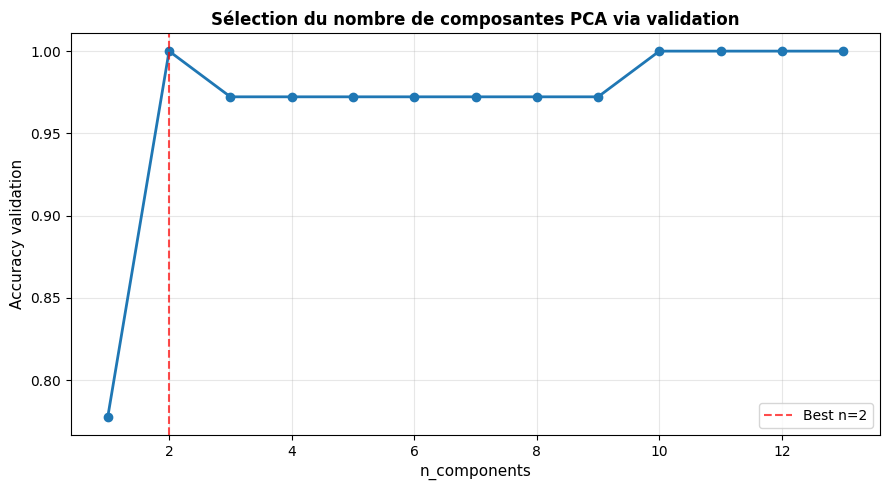

In [13]:
# 5) Visualisation: sélection du nombre de composantes
plt.figure(figsize=(9, 5))
plt.plot(range(1, n_max + 1), val_scores, marker="o", linewidth=2, markersize=6)
plt.axvline(best_n, color="red", linestyle="--", alpha=0.7, label=f"Best n={best_n}")
plt.title("Sélection du nombre de composantes PCA via validation", fontsize=12, fontweight="bold")
plt.xlabel("n_components", fontsize=11)
plt.ylabel("Accuracy validation", fontsize=11)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()